In [1]:
import os
import sys
import numpy as np

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from preprocessing.event_preprocessing import (
    load_events,
    print_event_statistics,
    split_events_by_time
)

In [2]:
# Project root (go up 2 levels from notebooks/month2/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))

events_path = os.path.join(PROJECT_ROOT, "events/train/Train001/events.h5")
events = load_events(events_path)

print_event_statistics(events)

windows = split_events_by_time(events, window_size=20000)
print(f"Generated {len(windows)} windows")

print("Events per window:", [len(w) for w in windows[:5]])


Event Stream
Total events:     350,916
  ON events:      177,053 (50.5%)
  OFF events:     173,863 (49.5%)

Temporal:
  Duration:       3933.33 ms
  Event rate:     89216 events/sec

Spatial:
  X range:        [0, 359]
  Y range:        [0, 239]
Generated 119 windows
Events per window: [2524, 2944, 2934, 2954, 3005]


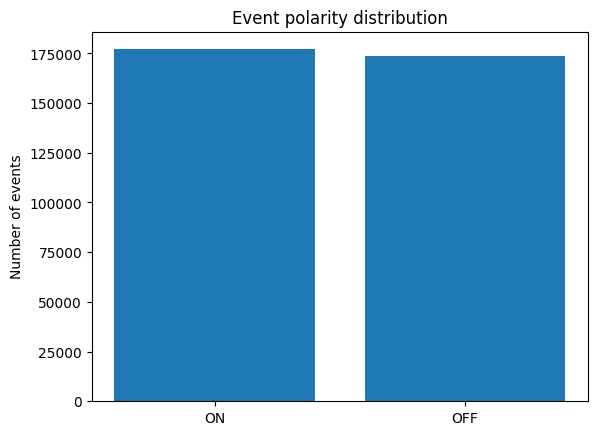

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Count polarities
on_count = np.sum(events['p'] == 1)
off_count = np.sum(events['p'] == 0)

plt.figure()
plt.bar(['ON', 'OFF'], [on_count, off_count])
plt.title("Event polarity distribution")
plt.ylabel("Number of events")
plt.show()


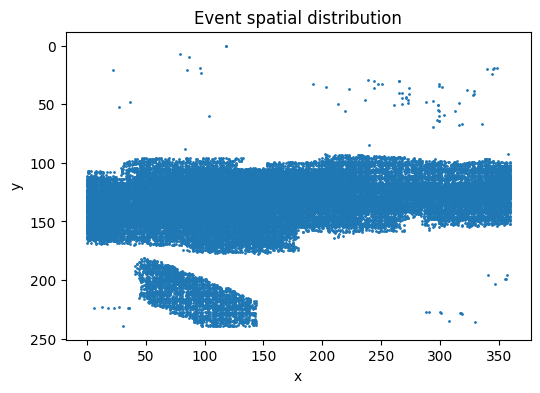

In [8]:
# Subsample for visualization (important!)
viz_events = events[np.random.choice(len(events), 50000, replace=False)]

plt.figure(figsize=(6, 4))
plt.scatter(viz_events['x'], viz_events['y'], s=1)
plt.gca().invert_yaxis()
plt.title("Event spatial distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


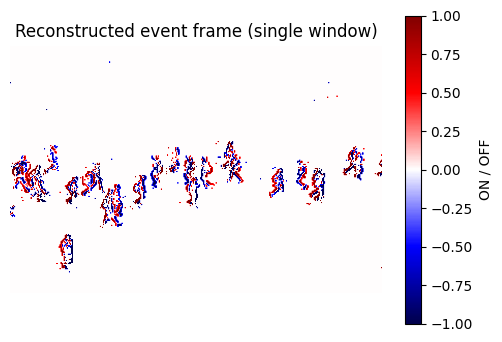

In [9]:
# Pick one window
window = windows[10]   # try different indices

H, W = 240, 360
frame = np.zeros((H, W), dtype=np.int32)

# Accumulate ON = +1, OFF = -1
for e in window:
    if e['p'] == 1:
        frame[e['y'], e['x']] += 1
    else:
        frame[e['y'], e['x']] -= 1

plt.figure(figsize=(6, 4))
plt.imshow(frame, cmap='seismic')
plt.colorbar(label='ON / OFF')
plt.title("Reconstructed event frame (single window)")
plt.axis('off')
plt.show()


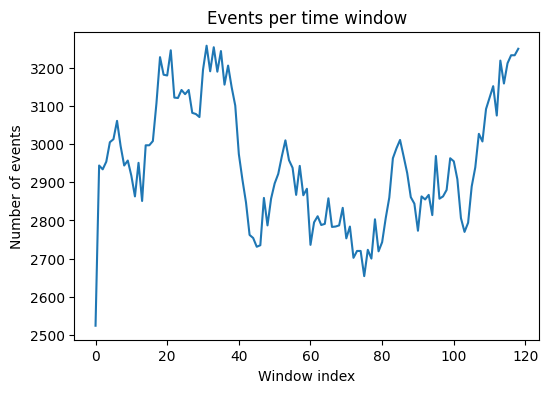

In [10]:
events_per_window = [len(w) for w in windows]

plt.figure(figsize=(6, 4))
plt.plot(events_per_window)
plt.title("Events per time window")
plt.xlabel("Window index")
plt.ylabel("Number of events")
plt.show()
